# Go2 ODD/COD Observer - Complete Workflow

This notebook demonstrates the complete workflow for analyzing Operational Design Domain (ODD) compliance and Conditions of Deployment (COD) for Unitree Go2 robot scenarios.

**Workflow Overview:**
1. Setup dependencies and configure Google AI SDK
2. Define ODD specifications in natural language
3. Instantiate multi-modal AI agents (Motion, Image, LiDAR, Collision)
4. Load and process scenario data
5. Evaluate ODD compliance and compute distance metrics
6. Visualize results and generate reports

**Note:** This workflow assumes you have preprocessed ROS2 bag files into time-windowed snapshots using the `extract_windows.py` script.

## 1. Setup and Dependencies

Install and import required packages for Google AI SDK and our analysis framework.

In [1]:
# Install Google Generative AI SDK and other dependencies
# Note: Run this cell only once or when packages need updating
!pip install -q google-generativeai google-cloud-aiplatform python-dotenv

In [2]:
# Import standard libraries
import os
import sys
import json
from pathlib import Path
from typing import Dict, List, Any, Tuple

# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Import Google Generative AI
import google.generativeai as genai
from google.generativeai import GenerativeModel
from google.generativeai.types import HarmCategory, HarmBlockThreshold

# Import our ODD/COD analysis framework
from odd_cod import (
    OddSpec,
    AxisSpecNumeric,
    AxisSpecCategorical,
    build_cod_vector,
    compute_window_distance,
    compute_window_odd_status,
    compute_scenario_distance,
    classify_scenario,
    compute_time_fractions,
)
from odd_cod.config_example import create_basic_indoor_odd, create_outdoor_rough_odd

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All imports successful")

/usr/local/python/current/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✓ All imports successful


## 2. Configure Google AI SDK

Set up authentication for Google Gemini API. You'll need a Google API key.

In [3]:
# Configure Google API key
# Option 1: Set via environment variable
# export GOOGLE_API_KEY='your-api-key-here'

# Option 2: Load from .env file
from dotenv import load_dotenv
load_dotenv()

# Option 3: Set directly (not recommended for production)
# os.environ['GOOGLE_API_KEY'] = 'your-api-key-here'

# Configure the SDK
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')
if GOOGLE_API_KEY:
    genai.configure(api_key=GOOGLE_API_KEY)
    print("✓ Google AI SDK configured")
else:
    print("⚠ GOOGLE_API_KEY not found. Using demo mode with placeholder agents.")
    print("  To enable real AI analysis, set your API key in environment or .env file.")

⚠ GOOGLE_API_KEY not found. Using demo mode with placeholder agents.
  To enable real AI analysis, set your API key in environment or .env file.


## 3. Define Operational Design Domain (ODD)

Specify the operating constraints for the Go2 robot using natural language boundaries.

In [4]:
# Create an ODD specification for indoor operation
# This defines the safe operating envelope for the robot
odd_spec = OddSpec(
    version="1.0",
    description="Indoor navigation ODD for Go2 robot in office environments",
    axes={
        "speed": AxisSpecNumeric(
            feature="forward_velocity",
            units="m/s",
            in_odd=[0.0, 1.5],        # Safe operating range
            near_boundary=[0.0, 1.8],  # Warning zone
            hard_limit=[0.0, 2.5]      # Physical/safety limit
        ),
        "roll_pitch": AxisSpecNumeric(
            feature="max_abs_roll_pitch",
            units="degrees",
            in_odd=[0.0, 15.0],
            near_boundary=[0.0, 20.0],
            hard_limit=[0.0, 30.0]
        ),
        "terrain": AxisSpecCategorical(
            feature="terrain_type",
            allowed_in_odd=["smooth", "moderate"],
            allowed_all=["smooth", "moderate", "rough", "very_rough"]
        ),
        "lighting": AxisSpecCategorical(
            feature="lighting_condition",
            allowed_in_odd=["bright", "dim"],
            allowed_all=["bright", "dim", "dark"]
        ),
        "humans": AxisSpecCategorical(
            feature="human_proximity",
            allowed_in_odd=["none", "visible_far"],
            allowed_all=["none", "visible_far", "very_close"]
        ),
        "collision": AxisSpecCategorical(
            feature="collision_state",
            allowed_in_odd=["no_collision"],
            allowed_all=["no_collision", "collision_suspected"]
        ),
    },
    importance={
        "speed": 1.0,
        "roll_pitch": 1.2,  # Safety critical
        "terrain": 0.8,
        "lighting": 0.5,
        "humans": 1.5,      # Very important for safety
        "collision": 2.0,   # Highest priority
    }
)

print("✓ ODD specification created")
print(f"  Version: {odd_spec.version}")
print(f"  Axes: {', '.join(odd_spec.axes.keys())}")
print(f"\nDescription: {odd_spec.description}")

✓ ODD specification created
  Version: 1.0
  Axes: speed, roll_pitch, terrain, lighting, humans, collision

Description: Indoor navigation ODD for Go2 robot in office environments


## 4. Instantiate Multi-Modal AI Agents

Create specialized agents for analyzing different sensor modalities using Google Gemini 2.5 Flash.

In [5]:
# Configure safety settings for Gemini
safety_settings = {
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
}

# Model configuration
model_config = {
    "temperature": 0.1,  # Low temperature for consistent, factual analysis
    "top_p": 0.95,
    "top_k": 40,
}

# Initialize Gemini model for multi-modal analysis
if GOOGLE_API_KEY:
    model = GenerativeModel(
        model_name="gemini-2.0-flash-exp",  # or "gemini-1.5-pro" for more complex reasoning
        generation_config=model_config,
        safety_settings=safety_settings
    )
    print("✓ Gemini model initialized")
else:
    model = None
    print("⚠ Running in demo mode without AI model")

⚠ Running in demo mode without AI model


### 4.1 Motion Agent

Analyzes motion data (velocity, IMU, odometry) to extract speed and orientation metrics.

In [6]:
def analyze_motion_with_gemini(motion_data: Dict, model: GenerativeModel) -> Dict[str, Any]:
    """
    Use Gemini to analyze motion time series data.
    
    Args:
        motion_data: Dictionary with motion time series (velocity, IMU, etc.)
        model: Gemini model instance
        
    Returns:
        Dictionary with extracted motion features
    """
    prompt = f"""
You are a motion analysis expert for quadruped robots. Analyze the following motion data and extract key features.

Motion Data:
- Command velocities (cmd_vx): {motion_data.get('cmd_vx', [])[:10]} ... (first 10 samples)
- Odometry velocities (odom_vx): {motion_data.get('odom_vx', [])[:10]} ... (first 10 samples)
- Roll angles (degrees): {motion_data.get('roll', [])[:10]} ... (first 10 samples)
- Pitch angles (degrees): {motion_data.get('pitch', [])[:10]} ... (first 10 samples)
- Acceleration X (m/s²): {motion_data.get('accel_x', [])[:10]} ... (first 10 samples)

Provide your analysis in JSON format with these exact fields:
{{
    "avg_forward_speed": <float>,
    "max_forward_speed": <float>,
    "max_abs_roll_pitch_deg": <float>,
    "tracking_error": <float>,
    "motion_label": "smooth" or "dynamic"
}}

Only respond with valid JSON, no additional text.
"""
    
    try:
        response = model.generate_content(prompt)
        # Parse JSON from response
        result_text = response.text.strip()
        # Remove markdown code blocks if present
        if result_text.startswith('```'):
            result_text = result_text.split('```')[1]
            if result_text.startswith('json'):
                result_text = result_text[4:]
            result_text = result_text.strip()
        return json.loads(result_text)
    except Exception as e:
        print(f"Warning: Gemini analysis failed: {e}")
        # Fallback to simple heuristics
        return analyze_motion_heuristic(motion_data)


def analyze_motion_heuristic(motion_data: Dict) -> Dict[str, Any]:
    """
    Simple heuristic-based motion analysis (fallback when AI is unavailable).
    """
    odom_vx = np.array(motion_data.get("odom_vx", [0.0]))
    cmd_vx = np.array(motion_data.get("cmd_vx", [0.0]))
    rolls = np.array(motion_data.get("roll", [0.0]))
    pitches = np.array(motion_data.get("pitch", [0.0]))
    
    avg_speed = float(np.mean(odom_vx))
    max_speed = float(np.max(np.abs(odom_vx)))
    max_roll_pitch = float(max(np.max(np.abs(rolls)), np.max(np.abs(pitches))))
    tracking_error = float(np.mean(np.abs(cmd_vx - odom_vx)))
    
    return {
        "avg_forward_speed": avg_speed,
        "max_forward_speed": max_speed,
        "max_abs_roll_pitch_deg": max_roll_pitch,
        "tracking_error": tracking_error,
        "motion_label": "smooth" if tracking_error < 0.1 else "dynamic",
    }

print("✓ Motion Agent defined")

✓ Motion Agent defined


### 4.2 Image Agent

Analyzes camera images to detect lighting conditions, human presence, and environment type.

In [7]:
def analyze_image_with_gemini(image_path: Path, model: GenerativeModel) -> Dict[str, Any]:
    """
    Use Gemini Vision to analyze camera images.
    
    Args:
        image_path: Path to camera image file
        model: Gemini model instance
        
    Returns:
        Dictionary with image analysis results
    """
    prompt = """
You are a computer vision expert analyzing robot camera feeds. Analyze this image and classify:

1. Lighting condition: "bright", "dim", or "dark"
2. Human presence:
   - Are humans visible? (true/false)
   - Are humans very close to camera? (true/false)
3. Environment type: "indoor_office", "indoor_home", "outdoor", "warehouse", etc.

Provide your analysis in JSON format with these exact fields:
{
    "lighting_class": "bright" | "dim" | "dark",
    "humans_visible": true | false,
    "humans_very_close": true | false,
    "environment_type": <string>
}

Only respond with valid JSON, no additional text.
"""
    
    try:
        # Load image
        img = Image.open(image_path)
        
        # Generate analysis
        response = model.generate_content([prompt, img])
        
        # Parse JSON from response
        result_text = response.text.strip()
        if result_text.startswith('```'):
            result_text = result_text.split('```')[1]
            if result_text.startswith('json'):
                result_text = result_text[4:]
            result_text = result_text.strip()
        return json.loads(result_text)
    except Exception as e:
        print(f"Warning: Gemini image analysis failed: {e}")
        # Fallback to default values
        return {
            "lighting_class": "bright",
            "humans_visible": False,
            "humans_very_close": False,
            "environment_type": "indoor_office",
        }

print("✓ Image Agent defined")

✓ Image Agent defined


### 4.3 LiDAR Agent

Analyzes multi-channel Bird's Eye View (BEV) images to classify terrain roughness and obstacles.

In [8]:
def analyze_lidar_with_gemini(bev_paths: Dict[str, Path], model: GenerativeModel) -> Dict[str, Any]:
    """
    Use Gemini Vision to analyze LiDAR BEV images.
    
    Args:
        bev_paths: Dictionary with paths to BEV channel images (occupancy, height, density, roughness)
        model: Gemini model instance
        
    Returns:
        Dictionary with terrain classification results
    """
    prompt = """
You are analyzing Bird's Eye View (BEV) LiDAR representations for a quadruped robot. You are given 4 channel images:

1. Occupancy: Binary presence grid (white = occupied)
2. Height: Elevation map (brighter = higher)
3. Density: Point cloud density (brighter = more points)
4. Roughness: Terrain roughness (brighter = rougher)

Classify the terrain:
- "smooth": Flat, even surface (e.g., smooth floor)
- "moderate": Some unevenness but navigable
- "rough": Uneven terrain with obstacles
- "very_rough": Highly irregular terrain

Also estimate obstacle density: "none", "low", "medium", "high"

Provide your analysis in JSON format:
{
    "terrain_roughness_class": "smooth" | "moderate" | "rough" | "very_rough",
    "terrain_roughness_score": <float 0-1>,
    "obstacle_density": "none" | "low" | "medium" | "high"
}

Only respond with valid JSON, no additional text.
"""
    
    try:
        # Load all BEV channel images
        images = []
        for channel in ['occupancy', 'height', 'density', 'roughness']:
            if channel in bev_paths and bev_paths[channel].exists():
                images.append(Image.open(bev_paths[channel]))
        
        if not images:
            raise ValueError("No BEV images found")
        
        # Generate analysis with all images
        response = model.generate_content([prompt] + images)
        
        # Parse JSON from response
        result_text = response.text.strip()
        if result_text.startswith('```'):
            result_text = result_text.split('```')[1]
            if result_text.startswith('json'):
                result_text = result_text[4:]
            result_text = result_text.strip()
        return json.loads(result_text)
    except Exception as e:
        print(f"Warning: Gemini LiDAR analysis failed: {e}")
        # Fallback to default values
        return {
            "terrain_roughness_class": "smooth",
            "terrain_roughness_score": 0.1,
            "obstacle_density": "low",
        }

print("✓ LiDAR Agent defined")

✓ LiDAR Agent defined


### 4.4 Collision Agent

Fuses motion, camera, and LiDAR data to detect potential collisions.

In [9]:
def analyze_collision_with_gemini(
    motion_tags: Dict,
    image_path: Path,
    bev_paths: Dict[str, Path],
    model: GenerativeModel
) -> Dict[str, Any]:
    """
    Use Gemini to detect collisions using multi-modal fusion.
    
    Args:
        motion_tags: Extracted motion features
        image_path: Path to camera image
        bev_paths: Paths to BEV images
        model: Gemini model instance
        
    Returns:
        Dictionary with collision analysis
    """
    prompt = f"""
You are analyzing robot sensor data to detect collisions. You have:

1. Motion data showing:
   - Tracking error: {motion_tags.get('tracking_error', 0):.3f}
   - Motion label: {motion_tags.get('motion_label', 'unknown')}
   
2. Camera image (visual evidence of obstacles/contact)

3. LiDAR BEV images (proximity to obstacles)

Determine if a collision occurred or is imminent:
- High tracking error suggests unexpected motion (possible collision)
- Camera may show contact points or very close obstacles
- LiDAR shows geometric proximity

Provide your analysis in JSON format:
{{
    "collision_suspected": true | false,
    "collision_confidence": <float 0-1>,
    "collision_type": "none" | "front_bump" | "side_contact" | "unknown"
}}

Only respond with valid JSON, no additional text.
"""
    
    try:
        # Load images
        images = [Image.open(image_path)]
        for channel in ['occupancy', 'height']:
            if channel in bev_paths and bev_paths[channel].exists():
                images.append(Image.open(bev_paths[channel]))
        
        # Generate analysis
        response = model.generate_content([prompt] + images)
        
        # Parse JSON from response
        result_text = response.text.strip()
        if result_text.startswith('```'):
            result_text = result_text.split('```')[1]
            if result_text.startswith('json'):
                result_text = result_text[4:]
            result_text = result_text.strip()
        return json.loads(result_text)
    except Exception as e:
        print(f"Warning: Gemini collision analysis failed: {e}")
        # Fallback to simple heuristic
        tracking_error = motion_tags.get('tracking_error', 0.0)
        return {
            "collision_suspected": tracking_error > 0.5,
            "collision_confidence": min(1.0, tracking_error),
            "collision_type": "unknown" if tracking_error > 0.5 else "none",
        }

print("✓ Collision Agent defined")

✓ Collision Agent defined


### 4.5 Data Source Agent

Classifies scenarios as simulated vs real based on sensor characteristics.

In [10]:
def classify_data_source(motion_tags: Dict, manifest_data: Dict = None) -> str:
    """
    Classify scenario as 'sim' or 'real'.
    
    Args:
        motion_tags: Motion analysis results
        manifest_data: Optional ground truth from manifest.csv
        
    Returns:
        'sim' or 'real'
    """
    # Check ground truth first
    if manifest_data and 'is_sim' in manifest_data:
        return 'sim' if manifest_data['is_sim'] else 'real'
    
    # Heuristic: Perfect tracking suggests simulation
    tracking_error = motion_tags.get('tracking_error', 0.5)
    if tracking_error < 0.01:
        return 'sim'
    else:
        return 'real'

print("✓ Data Source Agent defined")

✓ Data Source Agent defined


## 5. Load Scenario Data

Load preprocessed window data from a specific run.

In [11]:
# Configure data paths
DATA_DIR = Path("data/processed/runs")

# List available scenarios
if DATA_DIR.exists():
    scenarios = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f"✓ Found {len(scenarios)} scenarios:")
    for scenario in scenarios:
        print(f"  - {scenario.name}")
else:
    print("⚠ No processed data found.")
    print("  Please run extract_windows.py to process ROS bags first.")
    scenarios = []

✓ Found 2 scenarios:
  - demo_run
  - run_001


In [12]:
def load_scenario_windows(scenario_path: Path) -> pd.DataFrame:
    """
    Load window index for a scenario.
    
    Args:
        scenario_path: Path to scenario directory
        
    Returns:
        DataFrame with window metadata
    """
    # Find index CSV
    index_files = list(scenario_path.glob("index_*.csv"))
    if not index_files:
        return pd.DataFrame()
    
    return pd.read_csv(index_files[0])

# Load first scenario if available
if scenarios:
    scenario_path = scenarios[0]
    windows_df = load_scenario_windows(scenario_path)
    print(f"\n✓ Loaded {len(windows_df)} windows from {scenario_path.name}")
    if not windows_df.empty:
        print("\nWindow columns:", list(windows_df.columns))
        print("\nFirst window:")
        print(windows_df.iloc[0])
else:
    windows_df = pd.DataFrame()


✓ Loaded 10 windows from demo_run

Window columns: ['window_id', 'start_time', 'end_time', 'motion_path', 'cam_image_path', 'bev_image_path']

First window:
window_id                                 0
start_time                              0.0
end_time                                2.0
motion_path       motion_demo_run_w000.json
cam_image_path        cam_demo_run_w000.png
bev_image_path        bev_demo_run_w000.png
Name: 0, dtype: object


## 6. Process Windows and Evaluate ODD Compliance

Analyze each window using our multi-modal agents and compute ODD compliance.

In [13]:
def analyze_window(
    window_row: pd.Series,
    scenario_path: Path,
    odd_spec: OddSpec,
    model: GenerativeModel = None
) -> Dict[str, Any]:
    """
    Analyze a single window using all agents.
    
    Args:
        window_row: Row from windows DataFrame
        scenario_path: Path to scenario directory
        odd_spec: ODD specification
        model: Gemini model (optional)
        
    Returns:
        Complete window analysis results
    """
    # Load motion data
    motion_path = scenario_path / window_row["motion_path"]
    with open(motion_path, 'r') as f:
        motion_data = json.load(f)
    
    # Analyze motion
    if model:
        motion_tags = analyze_motion_with_gemini(motion_data, model)
    else:
        motion_tags = analyze_motion_heuristic(motion_data)
    
    # Analyze camera image
    cam_path = scenario_path / window_row["cam_image_path"]
    if model and cam_path.exists():
        image_tags = analyze_image_with_gemini(cam_path, model)
    else:
        image_tags = {
            "lighting_class": "bright",
            "humans_visible": False,
            "humans_very_close": False,
            "environment_type": "indoor_office",
        }
    
    # Analyze LiDAR BEV
    # Note: Multi-channel BEV paths need to be parsed from window metadata
    bev_base = scenario_path / window_row.get("bev_image_path", "")
    bev_paths = {}
    if bev_base.exists():
        # Try to find multi-channel BEV images
        base_name = bev_base.stem
        for channel in ['occupancy', 'height', 'density', 'roughness']:
            channel_path = bev_base.parent / f"{base_name.replace('bev', f'bev_{channel}')}.png"
            if channel_path.exists():
                bev_paths[channel] = channel_path
    
    if model and bev_paths:
        lidar_tags = analyze_lidar_with_gemini(bev_paths, model)
    else:
        lidar_tags = {
            "terrain_roughness_class": "smooth",
            "terrain_roughness_score": 0.1,
            "obstacle_density": "low",
        }
    
    # Analyze collision
    if model and cam_path.exists():
        collision_tags = analyze_collision_with_gemini(motion_tags, cam_path, bev_paths, model)
    else:
        tracking_error = motion_tags.get('tracking_error', 0.0)
        collision_tags = {
            "collision_suspected": tracking_error > 0.5,
            "collision_confidence": min(1.0, tracking_error),
            "collision_type": "unknown" if tracking_error > 0.5 else "none",
        }
    
    # Merge all tags
    merged_tags = {
        **motion_tags,
        **image_tags,
        **lidar_tags,
        **collision_tags,
    }
    
    # Build COD vector and compute distance
    cod_vector = build_cod_vector(merged_tags, odd_spec)
    window_distance, axis_distances, axis_statuses = compute_window_distance(cod_vector, odd_spec)
    odd_status = compute_window_odd_status(axis_statuses)
    
    return {
        "window_id": window_row["window_id"],
        "start_time": window_row["start_time"],
        "tags": merged_tags,
        "cod_vector": cod_vector,
        "distance": window_distance,
        "axis_distances": axis_distances,
        "axis_statuses": axis_statuses,
        "odd_status": odd_status,
    }

print("✓ Window analysis function defined")

✓ Window analysis function defined


In [14]:
# Process all windows in the scenario
if not windows_df.empty:
    print(f"Processing {len(windows_df)} windows...\n")
    
    window_results = []
    for idx, window_row in windows_df.iterrows():
        result = analyze_window(window_row, scenario_path, odd_spec, model)
        window_results.append(result)
        
        # Print summary for first few windows
        if idx < 3:
            print(f"Window {result['window_id']} (t={result['start_time']:.1f}s):")
            print(f"  Distance: {result['distance']:.3f}")
            print(f"  Status: {result['odd_status']}")
            print(f"  Speed: {result['tags']['avg_forward_speed']:.2f} m/s")
            print(f"  Roll/Pitch: {result['tags']['max_abs_roll_pitch_deg']:.1f}°")
            print(f"  Collision: {result['tags']['collision_suspected']}")
            print()
    
    print(f"✓ Processed all {len(window_results)} windows")
else:
    print("⚠ No windows to process")
    window_results = []

Processing 10 windows...

Window 0 (t=0.0s):
  Distance: 0.094
  Status: in_odd
  Speed: 1.02 m/s
  Roll/Pitch: 6.1°
  Collision: False

Window 1 (t=1.0s):
  Distance: 0.094
  Status: in_odd
  Speed: 1.07 m/s
  Roll/Pitch: 5.5°
  Collision: False



Window 2 (t=2.0s):
  Distance: 0.094
  Status: in_odd
  Speed: 1.07 m/s
  Roll/Pitch: 4.7°
  Collision: False



✓ Processed all 10 windows


## 7. Compute Scenario-Level Metrics

Aggregate window results to evaluate overall scenario compliance.

In [15]:
if window_results:
    # Extract window distances and statuses
    window_distances = [r["distance"] for r in window_results]
    window_statuses = [r["odd_status"] for r in window_results]
    
    # Compute scenario distance
    scenario_distance = compute_scenario_distance(window_distances, window_statuses)
    
    # Compute time fractions
    time_fractions = compute_time_fractions(window_statuses)
    
    # Classify scenario
    exit_fraction = time_fractions["odd_exit"]
    scenario_class = classify_scenario(scenario_distance, exit_fraction)
    
    # Display results
    print("=" * 60)
    print("SCENARIO ANALYSIS SUMMARY")
    print("=" * 60)
    print(f"Scenario: {scenario_path.name}")
    print(f"Total Windows: {len(window_results)}")
    print(f"\nScenario Distance: {scenario_distance:.3f}")
    print(f"Classification: {scenario_class}")
    print(f"\nTime Distribution:")
    print(f"  In ODD: {time_fractions['in_odd']:.1%}")
    print(f"  Near Boundary: {time_fractions['near_boundary']:.1%}")
    print(f"  ODD Exit: {time_fractions['odd_exit']:.1%}")
    print("=" * 60)
else:
    print("No results to summarize")

SCENARIO ANALYSIS SUMMARY
Scenario: demo_run
Total Windows: 10

Scenario Distance: 0.066
Classification: IN_ODD

Time Distribution:
  In ODD: 100.0%
  Near Boundary: 0.0%
  ODD Exit: 0.0%


## 8. Visualize Results

Create visualizations to understand ODD compliance over time.

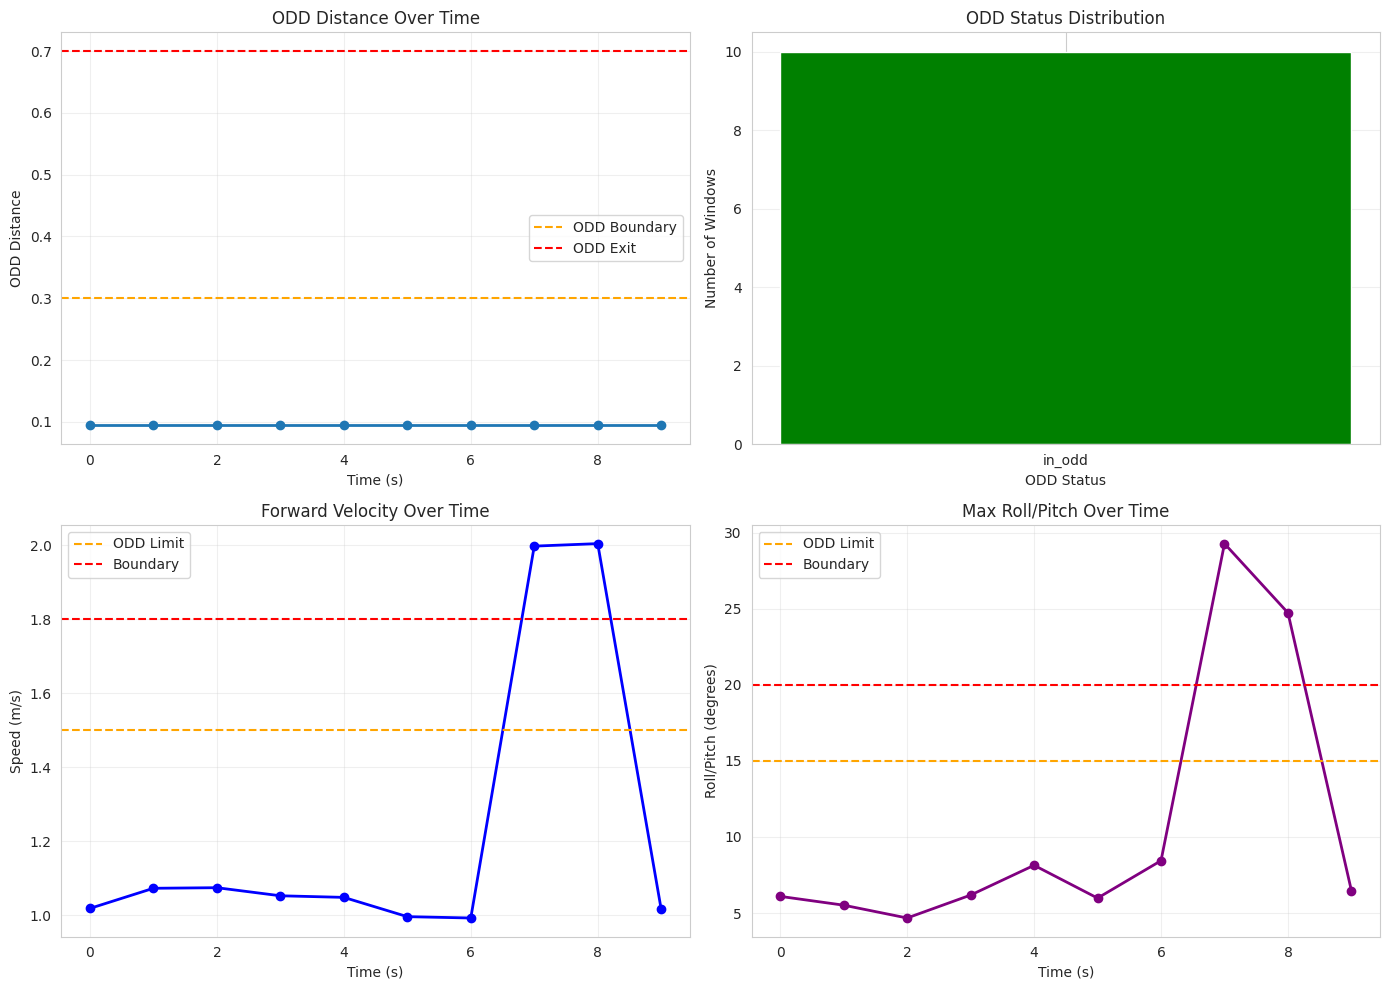

✓ Visualizations generated


In [16]:
if window_results:
    # Create results DataFrame for plotting
    results_df = pd.DataFrame([
        {
            'window_id': r['window_id'],
            'time': r['start_time'],
            'distance': r['distance'],
            'status': r['odd_status'],
            'speed': r['tags']['avg_forward_speed'],
            'roll_pitch': r['tags']['max_abs_roll_pitch_deg'],
            'collision': r['tags']['collision_suspected'],
        }
        for r in window_results
    ])
    
    # Plot 1: Distance over time
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Distance timeline
    ax = axes[0, 0]
    ax.plot(results_df['time'], results_df['distance'], marker='o', linewidth=2)
    ax.axhline(y=0.3, color='orange', linestyle='--', label='ODD Boundary')
    ax.axhline(y=0.7, color='red', linestyle='--', label='ODD Exit')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ODD Distance')
    ax.set_title('ODD Distance Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Status distribution
    ax = axes[0, 1]
    status_counts = results_df['status'].value_counts()
    colors = {'in_odd': 'green', 'near_boundary': 'orange', 'odd_exit': 'red'}
    ax.bar(status_counts.index, status_counts.values, 
           color=[colors.get(s, 'gray') for s in status_counts.index])
    ax.set_xlabel('ODD Status')
    ax.set_ylabel('Number of Windows')
    ax.set_title('ODD Status Distribution')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Speed over time
    ax = axes[1, 0]
    ax.plot(results_df['time'], results_df['speed'], marker='o', color='blue', linewidth=2)
    speed_spec = odd_spec.axes['speed']
    ax.axhline(y=speed_spec.in_odd[1], color='orange', linestyle='--', label='ODD Limit')
    ax.axhline(y=speed_spec.near_boundary[1], color='red', linestyle='--', label='Boundary')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed (m/s)')
    ax.set_title('Forward Velocity Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Roll/Pitch over time
    ax = axes[1, 1]
    ax.plot(results_df['time'], results_df['roll_pitch'], marker='o', color='purple', linewidth=2)
    rp_spec = odd_spec.axes['roll_pitch']
    ax.axhline(y=rp_spec.in_odd[1], color='orange', linestyle='--', label='ODD Limit')
    ax.axhline(y=rp_spec.near_boundary[1], color='red', linestyle='--', label='Boundary')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Roll/Pitch (degrees)')
    ax.set_title('Max Roll/Pitch Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualizations generated")
else:
    print("No data to visualize")

## 9. Generate Final Report

Create a comprehensive summary of the ODD/COD analysis.

In [17]:
if window_results:
    # Compile report data
    report = {
        "scenario_id": scenario_path.name,
        "odd_version": odd_spec.version,
        "total_windows": len(window_results),
        "scenario_distance": scenario_distance,
        "scenario_class": scenario_class,
        "time_fractions": time_fractions,
        "statistics": {
            "avg_speed": float(results_df['speed'].mean()),
            "max_speed": float(results_df['speed'].max()),
            "avg_roll_pitch": float(results_df['roll_pitch'].mean()),
            "max_roll_pitch": float(results_df['roll_pitch'].max()),
            "collision_count": int(results_df['collision'].sum()),
        },
        "violations": [
            {
                "window_id": r['window_id'],
                "time": r['start_time'],
                "distance": r['distance'],
                "violated_axes": [k for k, v in r['axis_statuses'].items() if v == 'out_of_odd']
            }
            for r in window_results
            if r['odd_status'] == 'odd_exit'
        ]
    }
    
    # Display report
    print("\n" + "=" * 60)
    print("FINAL ANALYSIS REPORT")
    print("=" * 60)
    print(f"\nScenario: {report['scenario_id']}")
    print(f"ODD Version: {report['odd_version']}")
    print(f"Windows Analyzed: {report['total_windows']}")
    print(f"\nOverall Assessment:")
    print(f"  Classification: {report['scenario_class']}")
    print(f"  Distance Score: {report['scenario_distance']:.3f}")
    print(f"\nTime in Each State:")
    print(f"  In ODD: {report['time_fractions']['in_odd']:.1%}")
    print(f"  Near Boundary: {report['time_fractions']['near_boundary']:.1%}")
    print(f"  ODD Exit: {report['time_fractions']['odd_exit']:.1%}")
    print(f"\nOperational Statistics:")
    print(f"  Average Speed: {report['statistics']['avg_speed']:.2f} m/s")
    print(f"  Maximum Speed: {report['statistics']['max_speed']:.2f} m/s")
    print(f"  Average Roll/Pitch: {report['statistics']['avg_roll_pitch']:.1f}°")
    print(f"  Maximum Roll/Pitch: {report['statistics']['max_roll_pitch']:.1f}°")
    print(f"  Collision Events: {report['statistics']['collision_count']}")
    
    if report['violations']:
        print(f"\nODD Violations ({len(report['violations'])}):")
        for v in report['violations'][:5]:  # Show first 5
            print(f"  - Window {v['window_id']} (t={v['time']:.1f}s): "
                  f"distance={v['distance']:.3f}, axes={v['violated_axes']}")
        if len(report['violations']) > 5:
            print(f"  ... and {len(report['violations']) - 5} more")
    else:
        print("\n✓ No ODD violations detected")
    
    print("=" * 60)
    
    # Save report to JSON
    report_path = scenario_path / "odd_analysis_report.json"
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"\n✓ Report saved to: {report_path}")
else:
    print("No data to report")


FINAL ANALYSIS REPORT

Scenario: demo_run
ODD Version: 1.0
Windows Analyzed: 10

Overall Assessment:
  Classification: IN_ODD
  Distance Score: 0.066

Time in Each State:
  In ODD: 100.0%
  Near Boundary: 0.0%
  ODD Exit: 0.0%

Operational Statistics:
  Average Speed: 1.23 m/s
  Maximum Speed: 2.00 m/s
  Average Roll/Pitch: 10.6°
  Maximum Roll/Pitch: 29.3°
  Collision Events: 0

✓ No ODD violations detected

✓ Report saved to: data/processed/runs/demo_run/odd_analysis_report.json


## 10. Summary and Next Steps

This notebook demonstrated the complete ODD/COD analysis workflow:

1. ✓ Set up Google AI SDK and dependencies
2. ✓ Defined ODD specifications with natural language boundaries
3. ✓ Instantiated multi-modal AI agents (Motion, Image, LiDAR, Collision)
4. ✓ Loaded and processed scenario data from preprocessed windows
5. ✓ Evaluated ODD compliance and computed distance metrics
6. ✓ Visualized results with timeline plots and distributions
7. ✓ Generated comprehensive analysis report

### Next Steps:

- **Process more scenarios**: Apply this workflow to additional runs from your ROS2 bags
- **Compare sim vs real**: Analyze differences in ODD compliance between simulation and real robot
- **Tune ODD specifications**: Adjust boundaries based on observed performance
- **Enhance agents**: Improve prompt engineering for more accurate multi-modal analysis
- **Export results**: Generate reports for stakeholders or competition submission

### Resources:

- [Kaggle 5-Day Agents Intensive](https://www.kaggle.com/learn-guide/5-day-agents)
- [Google Gemini API Documentation](https://ai.google.dev/docs)
- [Project Repository](https://github.com/danmartinez78/go2-odd-observer)